<a href="https://colab.research.google.com/github/idoco34/Alzheimer1/blob/main/%D7%A2%D7%99%D7%93%D7%95_%D7%A7%D7%95%D7%A8%D7%93%D7%95%D7%91%D7%94_%D7%96%D7%99%D7%94%D7%95%D7%99_%D7%90%D7%9C%D7%A6%D7%94%D7%99%D7%99%D7%9E%D7%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# הכנת הסביבה


Using the following data set:
https://huggingface.co/datasets/Falah/Alzheimer_MRI

In [1]:
#Import libraries

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import random
from pathlib import Path
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import files
from PIL import Image
from sklearn.metrics import confusion_matrix

# הכנת הנתונים

In [2]:
os.chdir('/content')

# List the contents of the /content directory
!ls -F /content/

drive/	      test-00000-of-00001-44110b9df98c5585.parquet
sample_data/  train-00000-of-00001-c08a401c53fe5312.parquet


In [4]:
#loads data from a given directory
def load_data_from_directory(file_path, label_prefix=""):
    temp_features = []
    temp_labels = []
    # Load the Parquet file
    df = pd.read_parquet(file_path)
    if 'label' in df.columns:
        temp_labels = df['label'].tolist()
        # Drop the label column and use the rest as features
        features_df = df.drop(columns=['label'])
        # Convert the features DataFrame to a list of arrays or a single array
        temp_features = features_df.values.tolist()
    return temp_features, temp_labels


In [44]:
#set hyper parameters

# Image Dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Training Parameters
EPOCHS = 5

# class types
class_names = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

In [6]:
#Load data from model files

feature_list = []
labels_list = []

# Load data from train directory
train_features, train_labels = load_data_from_directory('/content/train-00000-of-00001-c08a401c53fe5312.parquet', label_prefix='train_')
feature_list.extend(train_features)
labels_list.extend(train_labels)

# Load data from test directory
test_features, test_labels = load_data_from_directory('/content/test-00000-of-00001-44110b9df98c5585.parquet', label_prefix='test_')
feature_list.extend(test_features)
labels_list.extend(test_labels)

In [7]:
#Split the data into applicable arrays

# Convert the list of feature arrays and labels to numpy arrays
if feature_list: # Check if any data was loaded
    # Ensure all feature arrays have the same length before stacking
    # Find the maximum feature length
    max_features_len = max(len(f) for f in feature_list)
    # Pad smaller arrays with NaNs or zeros if necessary (depends on the data)
    # print(f"Expected feature length: {max_features_len}")
    inconsistent_lengths = [len(f) for f in feature_list if len(f) != max_features_len]
    if inconsistent_lengths:
        print(f"Warning: Inconsistent feature lengths found. Max length: {max_features_len}, Inconsistent lengths: {set(inconsistent_lengths)}. Skipping data points with inconsistent lengths.")
        # Filter features and labels based on max length
        consistent_data = [(f, l) for f, l in zip(feature_list, labels_list) if len(f) == max_features_len]
        feature_list = [d[0] for d in consistent_data]
        labels_list = [d[1] for d in consistent_data]
        print(f"Using {len(feature_list)} data points with consistent feature length.")


    x = np.array(feature_list)
    y = np.array(labels_list)

    print(f"\nLoaded {len(x)} data points.")
    print("Shape of x (features):", x.shape)
    print("Shape of y (labels):", y.shape)
    if len(y) > 0:
        print("First 5 labels:", y[:5])
        # print("First data point (flattened features):", x[0][:10]) # Print first 10 features of the first data point
else:
    print("\nNo data found or loaded from the specified train/test PARQUET files.")
    x = np.array([])
    y = np.array([])


Loaded 6400 data points.
Shape of x (features): (6400, 1)
Shape of y (labels): (6400,)
First 5 labels: [2 0 3 3 2]


נתוני גרף:

*    דמנציה קלה - חומרה: 3
*    דמנציה בינונית - חומרה: 4
*    ללא דמנציה - חומרה: 1
*    דמנציה קלה מאד - חומרה: 2






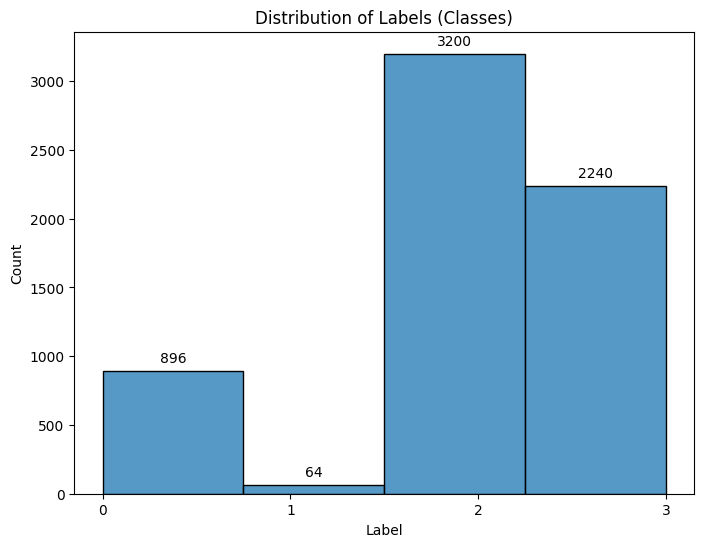

In [8]:
# Show data distribution

# Check if y is not empty before plotting
if y.size > 0:
    plt.figure(figsize=(8, 6))
    ax = sns.histplot(y, bins=len(np.unique(y)), kde=False)
    plt.title('Distribution of Labels (Classes)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(np.unique(y)) # Set x-ticks to the unique label values

    # Add counts above the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')
    plt.show()
else:
    print("Labels array (y) is empty. Cannot create a histogram.")

In [9]:
# Prepare image for the model

def preprocess_image(feature_dict):
    """Decodes, resizes, and normalizes an image from a feature dictionary."""
    # Get the image bytes from the dictionary
    image_bytes = feature_dict['bytes']

    # Decode the image
    image = tf.image.decode_jpeg(image_bytes, channels=3) # Decode as color image (3 channels)

    # Resize the image
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])

    # Normalize the image to the range [0, 1]
    image = image / 255.0

    return image

In [10]:
# Prepare all images

# Apply the preprocessing function to all features
# Ensure x contains dictionaries as expected
if len(x) > 0 and isinstance(x[0], np.ndarray) and len(x[0]) > 0 and isinstance(x[0][0], dict):
    # Extract the dictionaries from the numpy array structure
    feature_dicts = [item[0] for item in x]

    # Create a list to hold the processed images
    processed_images = []
    for feature_dict in feature_dicts:
        try:
            processed_image = preprocess_image(feature_dict)
            processed_images.append(processed_image.numpy()) # Convert TensorFlow tensor to NumPy array
        except tf.errors.InvalidArgumentError as e:
            print(f"Error processing image: {e}")
            # Optionally, skip or handle images that fail to decode/process
            pass # Skip the problematic image

    # Convert the list of processed images to a numpy array
    x_processed = np.array(processed_images)

    print("\nShape of processed features (images):", x_processed.shape)
    print("Data type of processed features:", x_processed.dtype)
    # Display the first processed image (as a numpy array)
    # print("First processed image (first few pixels):", x_processed[0, :10, :10, :]) # Print a small part
else:
    print("Features array (x) is not in the expected format for image preprocessing.")
    x_processed = np.array([]) # Initialize as empty if format is wrong


Shape of processed features (images): (6400, 128, 128, 3)
Data type of processed features: float32


In [13]:
# Split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# create and use x_val and y_val

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (4096, 128, 128, 3)
Shape of x_test: (1280, 128, 128, 3)
Shape of y_train: (4096,)
Shape of y_test: (1280,)


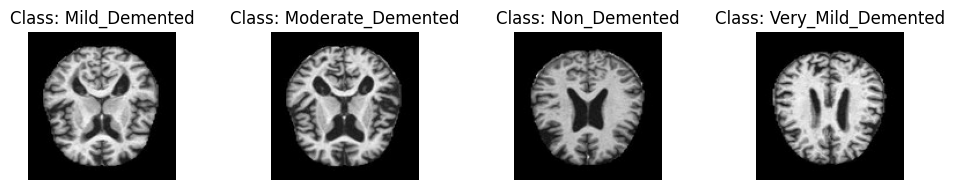

In [15]:
#Present example images

show = []
# Get the image array and its corresponding label
for i in range(4):
  # Select a random image index from the test set
  while True:
    random_index = random.randint(0, len(x_test) - 1)
    if i == y_test[random_index]:
      break
  image_to_display = x_test[random_index]
  label_to_display = y_test[random_index]
  show.append((image_to_display, label_to_display))

# Define the class names based on the dataset's README
class_names = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 2)) # 1 row, 4 columns

for i in range(4):
  image_to_display, label_to_display = show[i]
  label_name = class_names[label_to_display]

  # Display the image in the corresponding subplot
  axes[i].imshow(image_to_display)
  axes[i].set_title(f"Class: {label_name}")
  axes[i].axis('off') # Hide the axes

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

In [16]:
#Define model convolutional layers

# Define the input shape
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Determine the number of classes from the unique values in the labels
num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Create the Sequential model
model = Sequential([

    # First convolutional layer (with input_shape)
    Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Fourth convolutional layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten the output for the dense layers
    Flatten(),

    # Dense layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization

    # Output layer
    Dense(num_classes, activation='softmax') # Use softmax for multi-class classification
])

# Print the model summary
model.summary()

Number of classes: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,636 (3.13 MB)

 Trainable params: 821,636 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile the model

model.compile(optimizer=Adam(learning_rate=0.001),
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.


In [18]:
# Train the model

# Set number of epochs
history = model.fit(x_train, y_train, epochs=EPOCHS, validation_data=(x_val, y_val))

print("Model training complete.")

Epoch 1/5
102/128 ━━━━━━━━━━━━━━━━━━━━ 24s 930ms/step - accuracy: 0.4525 - loss: 1.1159

KeyboardInterrupt: 

In [19]:
#Mount drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Save model

#os.makedirs('/content/drive/MyDrive/models', exist_ok=True)
#model.save('/content/drive/MyDrive/models/model.keras')

In [20]:
#Load existing model

drive.mount('/drive')
model = tf.keras.models.load_model('/drive/MyDrive/models/model.keras')

Mounted at /drive


In [21]:
#Evaluate the model

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.1627
Test Accuracy: 0.9453


In [92]:
#Predict a single image

if len(x_test) > 0:
    img = random.randint(0, len(x_test) - 1)
    single_image_array = x_test[img] # Use the first image from the test set
else:
    print("Error: No test data available to use as an example.")
    single_image_array = None


if single_image_array is not None:
    single_image_input = np.expand_dims(single_image_array, axis=0)
    # Get the model's prediction probabilities for each class
    predictions = model.predict(single_image_input)
    # Get the predicted class index (the one with the highest probability)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    # Define the class names based on the dataset's README

    # Get the predicted class name
    predicted_class_name = class_names[predicted_class_index]
    print(f"\nImage index: {img}")
    print(f"\nThe model predicts this image belongs to the class: {predicted_class_name} {predictions[0][predicted_class_index]} ")
    print(f"\nThis Image belongs to the class: {class_names[y_test[img]]}")
    print(f"\nPrediction probabilities: {predictions[0]}")
else:
    print("\nCould not make a prediction as no image data was available.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Image index: 1194

The model predicts this image belongs to the class: Very_Mild_Demented 0.9676300883293152 

This Image belongs to the class: Very_Mild_Demented

Prediction probabilities: [1.4715171e-03 1.3557415e-05 3.0884782e-02 9.6763009e-01]


In [ ]:
predictions

array([[9.8987412e-01, 2.7589604e-05, 5.0553936e-06, 1.0093177e-02]],
      dtype=float32)

In [31]:
#Make a training and validation accuracy graph

#Plot training history
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, loss_values, 'b', label='Training loss') # Changed 'bo' to 'b'
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, accuracy_values, 'b', label='Training accuracy') # Changed 'bo' to 'b'
plt.plot(epochs, val_accuracy_values, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'history_dict' is not defined

40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 360ms/step


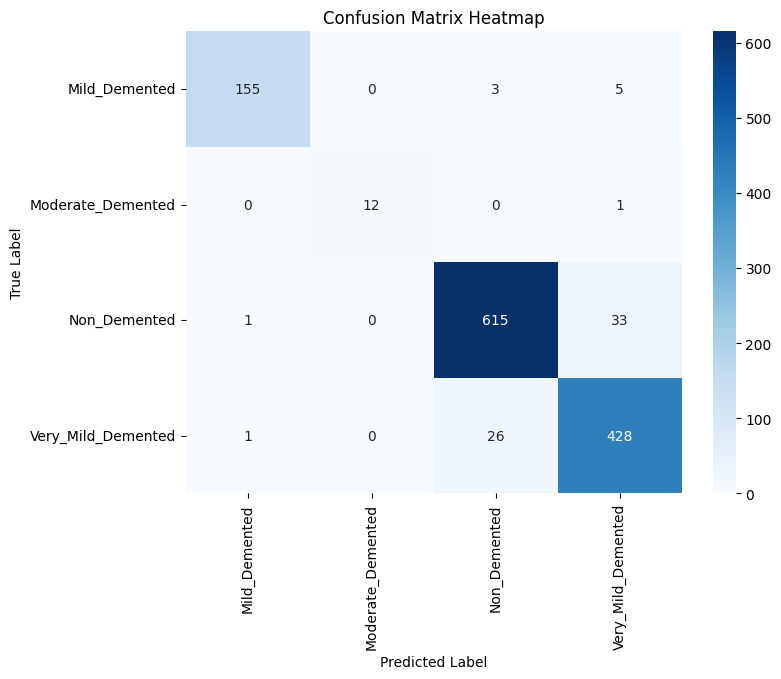

In [32]:
#make a confusion matrix

y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [70]:

def predict_image(img_array):
    # Step 1-6: Get bytes, open image, convert to RGB, resize, and reshape

  predictions = model.predict(img_array)
  mild = predictions[0][0]
  moderate = predictions[0][1]
  non_demented = predictions[0][2]
  very_mild = predictions[0][3]

  # Get the index of the highest value
  ind = np.argmax(predictions[0])

  if ind == 0:
    return "This image most likely belongs to the Mild Demented class. " + str(mild)
  if ind == 1:
    return "This image most likely belongs to the Moderate Demented class." + str(moderate)
  if ind == 2:
    return "This image most likely belongs to the Non Demented class." + str(non_demented)
  return "This image most likely belongs to the Very Mild Demented class." + str(very_mild)

In [ ]:
single_image_input = np.expand_dims(x_train[0], axis=0)
predict_image(single_image_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


'This image most likely belongs to the Non Demented class.0.9775655'

BELOW THIS LINE THE CODE IS FOR DEBUGGING PURPOSES...

In [105]:
#Save random image
from PIL import Image
import numpy as np

img = -1

if len(x_test) > 0:
    img = random.randint(0, len(x_test) - 1)
    single_image_array = x_test[img] # Use the first image from the test set
else:
    print("Error: No test data available to use as an example.")
    single_image_array = None

if single_image_array is not None:
  # Convert the float array (0-1) to uint8 (0-255)
  image_to_save = Image.fromarray((single_image_array * 255).astype(np.uint8))
  output_filename = "/media/" + class_names[y_test[img]] + "_" + str(img) + ".jpg"
  image_to_save.save(output_filename)
  print(f"Image saved successfully as {output_filename}")
else:
  print("No image array available to save.")

Image saved successfully as /media/Non_Demented_658.jpg


In [72]:
from PIL import Image
import numpy as np

# The filename from the previous cell
# Make sure output_filename variable is accessible from the previous cell or set it here
# For this example, let's assume it was '/media/Non_Demented_480.jpg'
# If the variable output_filename is not defined, you might need to adjust this.
output_filename = '/media/Non_Demented_480.jpg' # Uncomment and set if not globally available

if 'output_filename' in locals() or 'output_filename' in globals():
    try:
        # Load the image
        img_loaded = Image.open(output_filename)

        # Resize the image
        img_resized = img_loaded.resize((IMG_WIDTH, IMG_HEIGHT))

        # Convert to numpy array and normalize
        img_array = np.array(img_resized).astype('float32') / 255.0

        # Add a batch dimension to match x_test format (e.g., (1, 128, 128, 3))
        img_for_prediction = np.expand_dims(img_array, axis=0)

        print(f"Successfully loaded and transformed image: {output_filename}")
        print(f"Transformed image shape: {img_for_prediction.shape}")
        print(f"Transformed image data type: {img_for_prediction.dtype}")
    except FileNotFoundError:
        print(f"Error: The file {output_filename} was not found. Please ensure the previous cell saved the image correctly.")
    except Exception as e:
        print(f"An error occurred during image processing: {e}")
else:
    print("Error: The 'output_filename' variable was not found. Please make sure the previous cell has been executed and saved an image.")

predict_image(img_for_prediction)


Successfully loaded and transformed image: /media/Non_Demented_480.jpg
Transformed image shape: (1, 128, 128, 3)
Transformed image data type: float32
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


'This image most likely belongs to the Non Demented class.0.9994123'

In [ ]:
import io

def predict_image_2(img):

    # Step 1-6: Get bytes, open image, convert to RGB, resize, and reshape
  img_array = np.array(
      Image.open(io.BytesIO(img.get_bytes()))
      .convert('RGB')
      .resize((128, 128))
  ).reshape((128, 128, 3))  # Reshape to (128, 128, 3)

  single_image_input = np.expand_dims(img_array, axis=0)

  predictions = model.predict(single_image_input)
  mild = predictions[0][0]
  moderate = predictions[0][1]
  non_demented = predictions[0][2]
  very_mild = predictions[0][3]

  # Get the index of the highest value
  ind = np.argmax(predictions[0])

  if ind == 0:
    return "This image most likely belongs to the Mild Demented class. " + str(mild)
  if ind == 1:
    return "This image most likely belongs to the Moderate Demented class." + str(moderate)
  if ind == 2:
    return "This image most likely belongs to the Non Demented class." + str(non_demented)
  return "This image most likely belongs to the Very Mild Demented class." + str(very_mild)

In [74]:
import io
from PIL import Image
import numpy as np
import tensorflow as tf

# Redefine predict_image_2 to directly accept a PIL Image object
def predict_image_2(img):
    # img is now expected to be a PIL Image object
    img_array = np.array(
        img.convert('RGB')  # Convert the PIL Image to RGB
        .resize((128, 128))  # Resize the PIL Image
    )
    # Normalize the image to the range [0, 1]
    img_array = img_array.astype('float32') / 255.0

    single_image_input = np.expand_dims(img_array, axis=0)  # Add batch dimension

    predictions = model.predict(single_image_input, verbose=0) # Added verbose=0 to suppress output
    # The class_names list is available in the kernel state
    # class_names = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

    # Get the index of the highest value
    ind = np.argmax(predictions[0])
    predicted_class_name = class_names[ind]

    # Return the predicted class name and its probability
    return f"This image most likely belongs to the {predicted_class_name} class. Probability: {predictions[0][ind]:.4f}"


img = Image.open("/media/Non_Demented_479.jpg")
img.show()
predict_image_2(img)

'This image most likely belongs to the Non_Demented class. Probability: 1.0000'